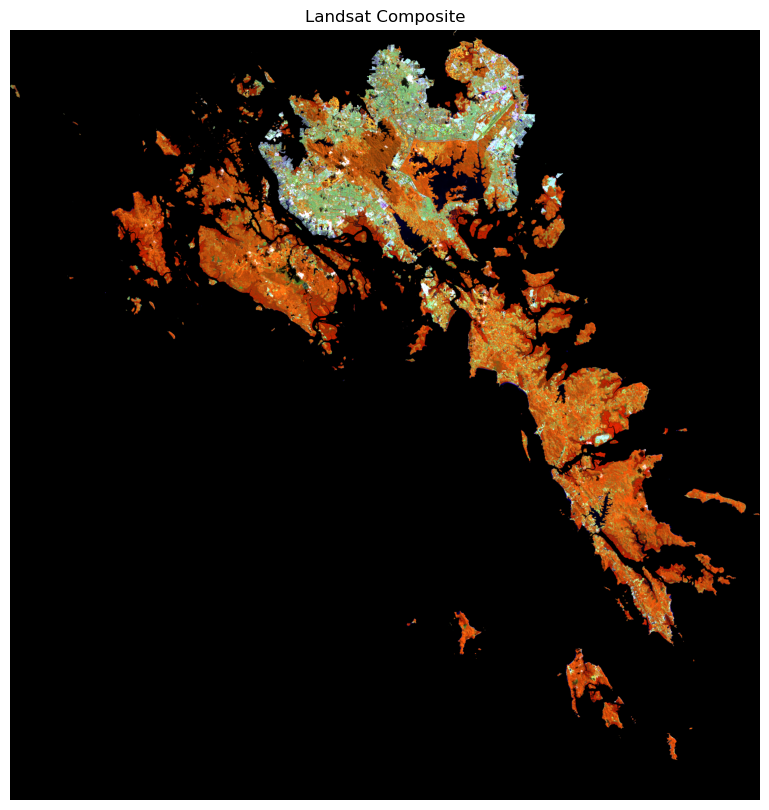

In [10]:
import os
import numpy as np
import geopandas as gpd
import rasterio as rio
from rasterio.plot import show
from rasterio.mask import mask
import matplotlib.pyplot as plt

# identify the boundaries
kota_utm = gpd.read_file('../data/boundaries/KOTA BATAM/kota_utm.geojson')
case_kota = kota_utm.copy()

kecamatan_utm = gpd.read_file('../data/boundaries/KOTA BATAM/kecamatan_utm.geojson')
case_kecamatan = kecamatan_utm[
    kecamatan_utm['NAMOBJ'] == 'Sei Beduk'
].copy()

# read data landasat collection
# detect landsat directory and simplify it, you can change based on your path
lc_path = '/Volumes/HOLMES/SATELLITE/landsat/20250706'

bands = {}
for band in range (1,8):
    bands[band] = rio.open(
        f"{lc_path}/LC09_L2SP_125059_20250706_20250707_02_T1_SR_B{band}.TIF"
    )

# clip raster to case 
def clip_band(src, boundary):
    clipped, transform = mask(
        src,
        boundary.geometry,
        crop=True
    )

    return clipped[0], transform 

clipped = {}

for band in bands:
    clipped[band], transform = clip_band(
        bands[band],
        case_kota
    )

# Bands composite visualization
def scale_sr(arr):
    return arr * 0.0000275 - 0.2

analysis = {}
for band in clipped:

    analysis[band] = scale_sr(
        clipped[band].astype("float32")
    )

def stretch(arr):
    valid = arr[arr > 0]
    p2 = np.percentile(valid, 2)
    p98 = np.percentile(valid, 98)
    arr = np.clip(arr, p2, p98)
    arr = (
        arr - p2
    ) / (
        p98 - p2
    )

    return arr

#Visulaize
rgb = np.dstack(
    (
        stretch(analysis[5]),
        stretch(analysis[6]),
        stretch(analysis[4])
    )
)

#plot RGB
plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.title('Landsat Composite')
plt.axis('off')
plt.show()
